# Модель для бесконтактного предсказания массы зеленной морской черепахи (Chelonia mydas)

Автор: Якунин Михаил

Дата: 12 апреля 2026 г.

## Цель проекта

Разработать линейную регрессионную модель для предсказания массы зелёных морских черепах (Chelonia mydas) по бесконтактным биометрическим измерениям (длина/ширина панциря, головы, ласт, количество колец роста и др.). Модель станет частью системы компьютерного зрения TurtleCV, позволяя заменить травматичное взвешивание на расчёт массы по внешним признакам.

## Постановка задачи машинного обучения

<u>**Обоснование выбора модели:**</u> 

Целевая переменная — масса черепахи (weight) — является непрерывной числовой величиной (измеряется в килограммах). Необходимо предсказать её точное значение на основе множества биометрических признаков, а не отнести черепаху к какому-либо классу (например, «лёгкая / средняя / тяжёлая»). Линейная регрессия выбрана в силу требования интерпретируемости коэффициентов для последующей реализации в виде простой формулы внутри прибора TurtleCV.

<u>**Почему целевая переменная `weight`:**</u>
* Именно массу необходимо определять бесконтактно, чтобы снизить стресс у животных.
* Все остальные поля (`shell_length`, `head_width`, `flipper_length_1` и т.д.) — это признаки, доступные через систему компьютерного зрения без физического контакта.
* Масса — ключевой параметр для дозирования лекарств, оценки реабилитации и решения о выпуске в океан.

<u>**Критерии качества модели:**</u>
| Критерий | Пороговое значение | Целевая аудитория / условие |
|----------|--------------------|------------------------------|
| MAE | ≤ 5 кг | Для черепах массой от 50 до 150 кг (взрослые особи). В случае наличия в данных более лёгких животных — ошибка может быть меньше, но 5 кг — жёсткая верхняя граница. |
| MAPE | Чем ниже, тем лучше. | Для всей выборки (разные возрастные группы). Позволяет убедиться, что модель не ошибается систематически на молодых черепахах. |
| R² | ≥ 0.97 | На валидационной и тестовой выборках. Гарантирует, что модель объясняет почти всю вариативность массы. |
| Линейность модели | Коэффициенты должны быть интерпретируемы, без нелинейных преобразований (кроме возможного масштабирования признаков) | Требование заказчика для простой реализации в приборе. |
| Воспроизводимость | Фиксированный random_state во всех случайных процессах (разбиение выборки, регуляризация и т.д.) | Обеспечивает повторяемость результатов. |

В рамках данного проекта решается задача регрессии с целевой переменной weight (масса черепахи, кг). Качество модели оценивается по трём метрикам: MAE ≤ 5 кг (для взрослых особей), MAPE (относительная ошибка) и R² ≥ 0.97 (доля объяснённой дисперсии). Успешной считается линейная модель, которая на тестовой выборке достигает всех трёх пороговых значений, сохраняя интерпретируемость коэффициентов и воспроизводимость результатов.

## Подключение и настройка библиотек

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Загрузка датасета

In [2]:
# Загружаем датасет
df = pd.read_csv('turtles.csv', sep='\t', decimal=',')

In [3]:
# Выводим общую информацию о датафрейме
display(df.head(5))
df.info()
df.describe(include='all').T

,id,binomial_name,registration number,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,measure_count,shell_crack,timestamp,weight
0,20438,Caretta caretta,d89af72662f49ece4d09dec75a8b0166,700.0,381,112.0,82.0,356,205,331,185,270.0,180.0,273.0,144.0,63,3.0,NaN,1703159226,87.687
1,19034,Lepidochelys olivacea,1579c64777de4db1c16e8b7b0d19c45e,341.0,295,65.0,48.0,216,190,229,186,164.0,182.0,180.0,149.0,0,1.0,1.0,1689428175,26.949
2,24689,LEPIDOCHELYS OLIVACEA,bfcec01187569615087e4d777c44985a,408.0,343,71.0,70.0,308,224,285,232,264.0,179.0,268.0,176.0,0,3.0,NaN,1745783111,30.016
3,17945,Lepidochelys Olivacea,2c159675aa28f0ea566fce2090bf4c82,512.0,432,98.0,95.0,334,317,364,284,NaN,NaN,NaN,NaN,3,4.0,1.0,1677757151,33.917
4,24543,lepidochelys olivacea,ecd22499761e2ac56a6d8eb765ec566d,408.0,307,50.0,54.0,280,168,269,218,199.0,165.0,209.0,180.0,0,4.0,1.0,1744455613,28.511


<class 'pandas.DataFrame'>
RangeIndex: 8861 entries, 0 to 8860
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   8861 non-null   int64  
 1   binomial_name        8812 non-null   str    
 2   registration number  8832 non-null   str    
 3   shell_length         8774 non-null   float64
 4   shell_width          8861 non-null   int64  
 5   head_length          8715 non-null   float64
 6   head_width           8715 non-null   float64
 7   flipper_length_1     8861 non-null   int64  
 8   flipper_width_1      8861 non-null   int64  
 9   flipper_length_2     8861 non-null   int64  
 10  flipper_width_2      8861 non-null   int64  
 11  flipper_length_3     8760 non-null   float64
 12  flipper_width_3      8760 non-null   float64
 13  flipper_length_4     8760 non-null   float64
 14  flipper_width_4      8760 non-null   float64
 15  circle_count         8861 non-null   int64  
 16 

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,8861.0,NaN,NaN,NaN,21359.335628,2263.08942,17438.0,19396.0,21357.0,23317.0,25279.0
binomial_name,8812,23,Lepidochelys olivacea,3372,NaN,NaN,NaN,NaN,NaN,NaN,NaN
registration number,8832,7819,754c28373496ea3b28a749b9453c213f,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
shell_length,8774.0,NaN,NaN,NaN,764.22202,640.408681,132.0,440.0,635.0,951.0,20240.0
shell_width,8861.0,NaN,NaN,NaN,598.832299,480.970492,78.0,341.0,487.0,794.0,11550.0
head_length,8715.0,NaN,NaN,NaN,123.341021,67.836566,19.0,73.0,106.0,158.0,515.0
head_width,8715.0,NaN,NaN,NaN,115.735169,62.326365,12.0,67.0,98.0,156.0,382.0
flipper_length_1,8861.0,NaN,NaN,NaN,497.551405,353.575213,60.0,296.0,416.0,571.0,2875.0
flipper_width_1,8861.0,NaN,NaN,NaN,380.594515,214.481679,34.0,228.0,332.0,493.0,1479.0
flipper_length_2,8861.0,NaN,NaN,NaN,498.22853,355.074883,57.0,296.0,417.0,572.0,2967.0


## Исследовательский анализ данных

Проведите исследовательский анализ данных:





7. Проверьте, одинаков ли масштаб признаков. Если он различается, предложите решение этой проблемы.
8. Проанализируйте корреляцию между признаками и целевой переменной с помощью вычислений и графически. Определите, все ли признаки нужны для дальнейшей работы.
9. Проверьте данные на мультиколлинеарность и решите, можно ли её устранить.

In [4]:
# Выводим информацию какие виды черепах представлены и в каком количестве
df['binomial_name'].value_counts()

binomial_name
Lepidochelys olivacea     3372
Chelonia mydas            2325
Caretta caretta            674
lepidochelys olivacea      416
Dermochelys coriacea       399
Eretmochelys imbricata     332
Lepidochelys Olivacea      285
chelonia mydas             252
Chelonia Mydas             177
LEPIDOCHELYS OLIVACEA      142
caretta caretta             90
CHELONIA MYDAS              75
Caretta Caretta             46
eretmochelys imbricata      41
dermochelys coriacea        40
CARETTA CARETTA             37
Eretmochelys Imbricata      28
Dermochelys Coriacea        27
Lepidochelys kempii         22
DERMOCHELYS CORIACEA        18
ERETMOCHELYS IMBRICATA       8
lepidochelys kempii          3
Lepidochelys Kempii          3
Name: count, dtype: int64

В столбце binomial_name представлены различные виды черепах. Так же имеет место написание одного и того же вида по разному. Так как требуется нам строить модель только для морских черепах вида "Chelonia mydas", то следует сначально нармолизовать все назнания и отфильтровать датфрейм по нужному виду черепах.

In [5]:
# Производим нормализацию данных в столбце "binomial_name"
df['binomial_name'] = df['binomial_name'].str.strip().str.lower()

In [6]:
# Выводим обновленную информацию о видах и количестве черепах
df['binomial_name'].value_counts()

binomial_name
lepidochelys olivacea     4215
chelonia mydas            2829
caretta caretta            847
dermochelys coriacea       484
eretmochelys imbricata     409
lepidochelys kempii         28
Name: count, dtype: int64

In [7]:
# Отфильтруем датафрейм по черепахи вида "chelonia mydas"
c_mydas_df = df[df['binomial_name'] == 'chelonia mydas']

In [8]:
# Вывидем общую информацию о новом датафрейме
c_mydas_df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,2829.0,NaN,NaN,NaN,21321.534464,2260.214349,17438.0,19324.0,21354.0,23273.0,25276.0
binomial_name,2829,1,chelonia mydas,2829,NaN,NaN,NaN,NaN,NaN,NaN,NaN
registration number,2825,2484,754c28373496ea3b28a749b9453c213f,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
shell_length,2794.0,NaN,NaN,NaN,1052.253758,582.266941,645.0,837.0,978.5,1177.75,12840.0
shell_width,2829.0,NaN,NaN,NaN,948.835277,519.814403,564.0,753.0,889.0,1060.0,11550.0
head_length,2790.0,NaN,NaN,NaN,170.202509,41.944288,87.0,138.0,164.0,196.0,328.0
head_width,2790.0,NaN,NaN,NaN,183.487097,45.950989,96.0,148.0,176.0,212.0,382.0
flipper_length_1,2829.0,NaN,NaN,NaN,613.509721,143.814403,339.0,503.0,588.0,702.0,1147.0
flipper_width_1,2829.0,NaN,NaN,NaN,550.534464,133.707295,245.0,449.0,527.0,634.0,1072.0
flipper_length_2,2829.0,NaN,NaN,NaN,613.161895,139.846498,327.0,505.0,590.0,707.0,1049.0


Проверим данные на явные дубликаты. Так как количество строк в датафрейме 2829, а при этом количество уникальных регистрационных номеров в столбце `registration number` только 2484.

In [9]:
# Выводим количество строк с дубликатами
c_mydas_df.duplicated().sum()

np.int64(341)

In [10]:
# Удаляем строки с явными дубликатами
c_mydas_df.drop_duplicates(subset=['registration number'], inplace=True)

Для обучения модели, нам требуются признаки с числовыми значениями. Поэтому из датафрейма `c_mydas_df` можно удалить столбцы `id`, `binomial_name`, `registration number`.
Так же можно удалить столбец `timestamp`, эти данные ни как не характерезуют вид черепахи. это всего лишь дата записи признаков. Столбец `measure_count`, тоже можно удалить, по пречине того, что количество проведенных измерений характерезует кажество измерений но не вид черепах. 

In [11]:
# Производим удаление не информативных признаков из датафрейма
c_mydas_df = c_mydas_df.drop(columns=['id', 'binomial_name', 'registration number', 'measure_count', 'timestamp'])
c_mydas_df.head(5)

,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,shell_crack,weight
8,742.0,652,118.0,147.0,411,386,507,389,414.0,368.0,311.0,325.0,66,1.0,56.352
11,1336.0,1318,207.0,248.0,845,704,661,768,587.0,686.0,661.0,585.0,111,5.0,154.074
16,1010.0,926,216.0,156.0,562,488,529,432,467.0,434.0,553.0,463.0,76,NaN,87.695
20,703.0,606,NaN,NaN,355,382,411,340,302.0,355.0,314.0,283.0,62,1.0,51.182
21,982.0,940,187.0,157.0,518,557,545,463,497.0,511.0,541.0,479.0,103,NaN,92.707


Проанализируем датафрейм на пропуски в ячейках.

In [12]:
c_mydas_df.isna().sum()

shell_length          29
shell_width            0
head_length           35
head_width            35
flipper_length_1       0
flipper_width_1        0
flipper_length_2       0
flipper_width_2        0
flipper_length_3      29
flipper_width_3       29
flipper_length_4      29
flipper_width_4       29
circle_count           0
shell_crack         1887
weight                 2
dtype: int64

Пустые ячейки скорее всего являются ошибкой выгрузки или ошибкой заполнения данных в процессе измерения. В любом случае, заполнять данные средним или иными данными не целесообразно, так как это может внести искожение в данные. По этому стоит строки с пустыми данными удалить. Это касается всех данных, кроме столбца `shell_crack`, здесь скорее пропуски обозначают тот факт что на панцере черепах отсутствуют трещины, поэтому значения не вносились. Поэтой причине, пустые ячейки в столбце `shell_crack` на референсное значение 0.

In [13]:
# Удаляем пустые строки
cols_to_drop = [col for col in c_mydas_df.columns if col != 'shell_crack']
c_mydas_df = c_mydas_df.dropna(subset=cols_to_drop)

In [14]:
# Заменяем пустые ячейки на 0 в столбце "shell_crack"
c_mydas_df['shell_crack'] = c_mydas_df['shell_crack'].fillna(0)

In [15]:
# Производим замену пустых ячеек
c_mydas_df.isna().sum()

shell_length        0
shell_width         0
head_length         0
head_width          0
flipper_length_1    0
flipper_width_1     0
flipper_length_2    0
flipper_width_2     0
flipper_length_3    0
flipper_width_3     0
flipper_length_4    0
flipper_width_4     0
circle_count        0
shell_crack         0
weight              0
dtype: int64

In [16]:
# Вывидем общую информацию о датафрейме
c_mydas_df.describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
shell_length,2393.0,1048.831174,575.012294,645.0,837.000,980.000,1170.000,12840.000
shell_width,2393.0,946.095278,515.280440,564.0,755.000,890.000,1055.000,11550.000
head_length,2393.0,169.585458,41.273452,87.0,138.000,163.000,195.000,328.000
head_width,2393.0,183.061429,45.096292,96.0,148.000,176.000,212.000,364.000
flipper_length_1,2393.0,612.027998,141.883960,339.0,502.000,588.000,702.000,1147.000
flipper_width_1,2393.0,549.522775,131.545246,245.0,450.000,528.000,631.000,1072.000
flipper_length_2,2393.0,611.806937,138.176561,327.0,505.000,591.000,703.000,1049.000
flipper_width_2,2393.0,550.672378,130.752992,276.0,449.000,534.000,635.000,997.000
flipper_length_3,2393.0,487.259089,110.145627,282.0,400.000,473.000,558.000,934.000
flipper_width_3,2393.0,440.603427,105.260452,231.0,357.000,426.000,511.000,837.000


В столбце с указанием массы черепах `weight`, есть строки с нуливыми значениями. Обучать модель на данных, где целевая переменная равна нулю нельзя, поэтому так же удалим из датафрема таки строки.

In [19]:
# Удаляем строки с 0 значением массы черепах
c_mydas_df = c_mydas_df[c_mydas_df['weight'] != 0]

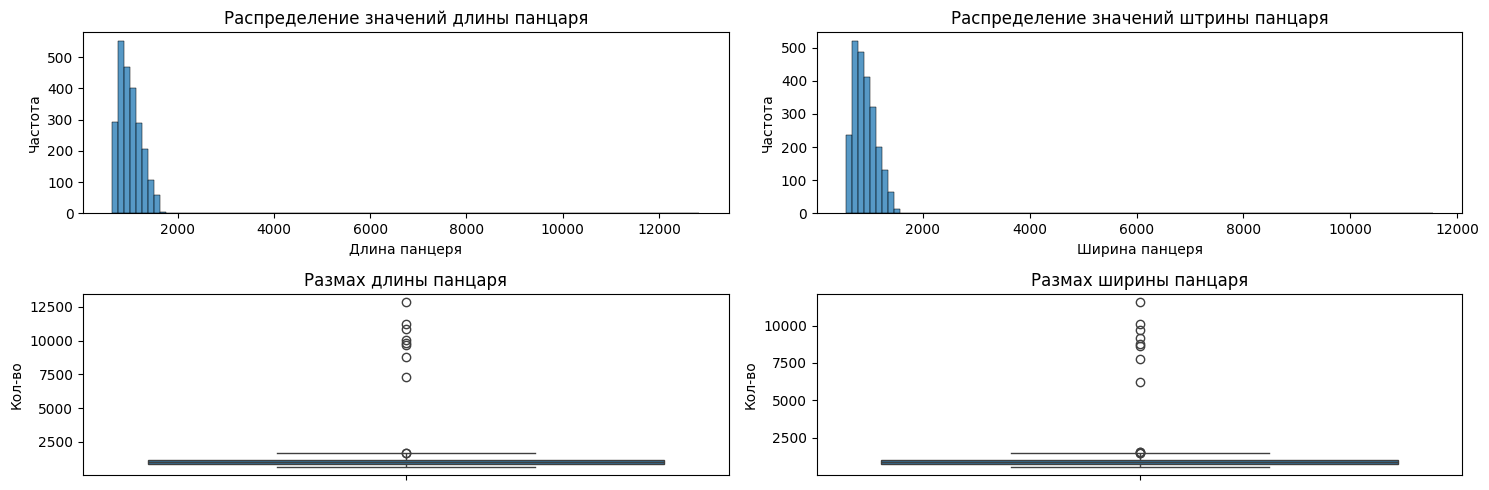

In [20]:
# Построим графики распределения и размаха длины и ширины панцеря
plt.figure(figsize=(15, 5))

plt.subplot(2, 2, 1)
sns.histplot(c_mydas_df['shell_length'])
plt.title('Распределение значений длины панцаря')
plt.xlabel('Длина панцеря')
plt.ylabel('Частота')

plt.subplot(2, 2, 2)
sns.histplot(c_mydas_df['shell_width'])
plt.title('Распределение значений штрины панцаря')
plt.xlabel('Ширина панцеря')
plt.ylabel('Частота')

plt.subplot(2, 2, 3)
sns.boxplot(c_mydas_df['shell_length'])
plt.title('Размах длины панцаря')
plt.ylabel('Кол-во')

plt.subplot(2, 2, 4)
sns.boxplot(c_mydas_df['shell_width'])
plt.title('Размах ширины панцаря')
plt.ylabel('Кол-во')

plt.tight_layout()
plt.show()

Как видем из графиком имеются выброссы. Но нам Заказчик сообщил, что во время измерений были ошибки с размерностью данных. Вместо указания значений в мм, измеренные данные были дополнительно умноженны на 10. Очень похоже что наши выбросы и есть ошибочные данные. Поэтому мы можем их поделить на 10.

In [21]:
# Произведем уменьшение разрядности данных
c_mydas_df.loc[c_mydas_df['shell_length'] > 2000] = c_mydas_df['shell_length'] / 10

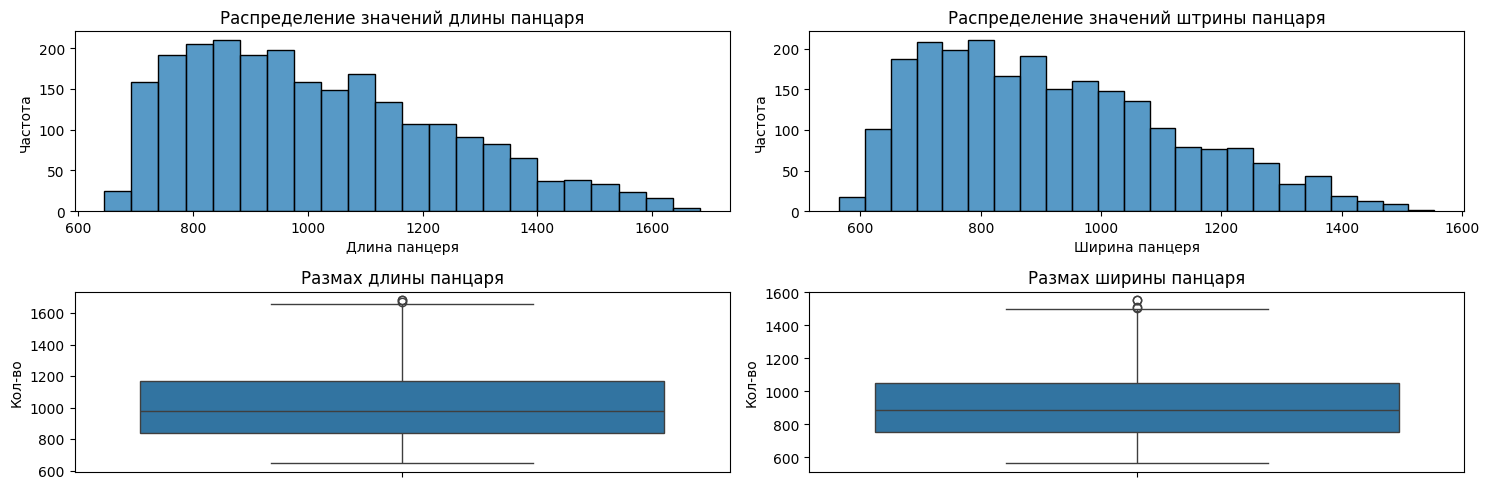

In [22]:
# Построим графики распределения и размаха длины и ширины панцеря
plt.figure(figsize=(15, 5))

plt.subplot(2, 2, 1)
sns.histplot(c_mydas_df['shell_length'])
plt.title('Распределение значений длины панцаря')
plt.xlabel('Длина панцеря')
plt.ylabel('Частота')

plt.subplot(2, 2, 2)
sns.histplot(c_mydas_df['shell_width'])
plt.title('Распределение значений штрины панцаря')
plt.xlabel('Ширина панцеря')
plt.ylabel('Частота')

plt.subplot(2, 2, 3)
sns.boxplot(c_mydas_df['shell_length'])
plt.title('Размах длины панцаря')
plt.ylabel('Кол-во')

plt.subplot(2, 2, 4)
sns.boxplot(c_mydas_df['shell_width'])
plt.title('Размах ширины панцаря')
plt.ylabel('Кол-во')

plt.tight_layout()
plt.show()

Теперь распределение данных стало нормального вида и графики размаха стали без явных выбросов. 

Оченим на сколько осталась репрезетативна выборка после всех предобработак.

In [37]:
# Расчитываем объем удаленных данных
print(f'Процент удаленных строк: {round(1 - c_mydas_df.shape[0] / df[df["binomial_name"] == "chelonia mydas"].shape[0], 2) * 100}%')

Процент удаленных строк: 16.0%


Исходя из того, что нами были удаленны случайные строки (явные дубликаты, технические сбои и т.д.), то удаление 16% данных не повлияет на репрезентативность. По этим можно строить модель машинного обучения.

## Предобработка данных

1. Разделите данные на выборки: обучающую (60%), валидационную (20%) и тестовую (20%). В реальных проектах стараются писать код предобработки так, чтобы предотвратить утечку данных. Это проще сделать, если сразу поделить данные.
2. Обработайте пропуски. При необходимости заполните их средними (медианными) значениями. Рассчитайте заполнитель только по обучающей выборке: это ещё одно правило для предотвращения утечки.
3. Напишите функцию для стандартизации признаков. Расчёт параметров масштабирования делайте только по обучающей выборке, чтобы не дать утечке ни малейшего шанса.
4. Напишите функцию для нормализации признаков.
5. Подготовьте несколько датасетов из трёх выборок каждый для дальнейшего обучения моделей с разным способом масштабирования: без масштабирования, с нормализацией, со стандартизацией.

## Обучение моделей

1. Постройте базовую модель (дамми), с которой будете сравнивать все остальные. Если они будут хуже базовой по качеству, это будет означать, что при обучении что-то пошло не так. Пример дамми: модель, которая всегда предсказывает среднее значение целевой переменной из обучающей выборки.
2. Обучите несколько архитектур линейных моделей. Они могут различаться по ряду черт: набором отобранных признаков, масштабом признаков, установленными гиперпараметрами, функциями потерь. Попробуйте обучить следующие модели:
   - `LinearRegression`;
   - `Lasso` (L1-регуляризация);
   - `Ridge` (L2-регуляризация);
   - `SGDRegressor`.
   
   Обязательно попробуйте модели с разными значениями гиперпараметра `loss`.
- **Бонусное задание.** Подумайте, можно ли улучшить модели за счёт создания новых признаков: например, умножив длину ласт на ширину. Проверьте, усилится ли корреляция нового признака с целевой переменной, возрастёт ли благодаря ему качество модели.
3. Сформируйте итоговую таблицу с результатами моделей. Это удобно сделать в виде датафрейма pandas. Включите в таблицу следующие столбцы:
   - Название модели.
   - Название датасета — оно должно указывать на то, какой способ масштабирования использовался при подготовке данных.
   - Метрики качества, рассчитанные на валидационной выборке. Основная метрика — MAE, дополнительные — MSE, R², MAPE и прочие.

## Сравнение моделей на валидационной выборке

1. Сравните построенные модели по метрикам на валидационной выборке. Удалось ли существенно улучшить результат базовой модели?
2. Выберите лучшую модель по основной метрике на валидационной выборке. Не заглядывайте в метрики на тестовой выборке раньше времени. Тестовая выборка не используется для обучения моделей, подбора гиперпараметров и сравнения моделей с разными значениями.
3. Напишите выводы о том, какая из моделей обладает лучшим качеством. Именно её одну далее нужно проверить на тестовой выборке для итоговой оценки.

## Проверка лучшей модели на тестовой выборке

1. Проверьте метрики лучшей модели на тестовой выборке.
2. Узнайте, есть ли признаки переобучения лучшей модели.
3. Определите, соответствует ли модель требованиям заказчика. Объясните, можно ли её рекомендовать к внедрению.

## Оценка важности признаков

1. Оцените важность признаков по абсолютным значениям весов лучшей модели.
2. Напишите, какие признаки стали для модели более важными. Объясните, согласны ли вы с таким результатом?

## Функция для прогнозирования веса черепахи

* Напишите на Python функцию, которая будет прогнозировать массу черепахи по заданным параметрам с учётом коэффициентов лучшей модели (свойство `coef_`) и смещения (свойство `intercept_`).
* Если вы столкнётесь с трудностями при написании функции, то представьте, что обращаетесь к старшему коллеге с просьбой помочь, и составьте задание для её написания. Подробно опишите логику, по которой рассчитывается масса черепахи, и укажите, как именно должны происходить расчёты.

## Общие выводы и рекомендации по дальнейшей работе

Напишите общие выводы и рекомендации по дальнейшей работе. Ответьте на вопросы:
  - Какие модели изучены?
  - Какие результаты получены?
  - Рекомендуется ли итоговая модель к внедрению?
  - Какая архитектура и способ обработки признаков показали себя лучше всего? Какие у них показатели метрик?
  - Какие признаки наиболее важны для модели?
  - Есть ли перспективы у обучения этой или других моделей для предсказания массы других видов черепах?
  - При наличии добавьте сюда свои предложения по дальнейшему развитию проекта.